In [1]:
!pip install cupy-cuda12x pycuda -q
import subprocess; print(subprocess.getoutput("nvidia-smi --query-gpu=name --format=csv,noheader"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 11.5 MB/s eta 0:00:00
Tesla T4


     N    CPU(ms)    GPU(ms)    H2D(ms)  Speedup
  2^10      0.012    493.711      2.192     0.00x
  2^14      0.015      0.091      1.503     0.16x
  2^18      0.166      0.072      0.666     2.31x
  2^22      5.205      0.515     21.729    10.11x
  2^26    102.693      3.464    336.562    29.65x


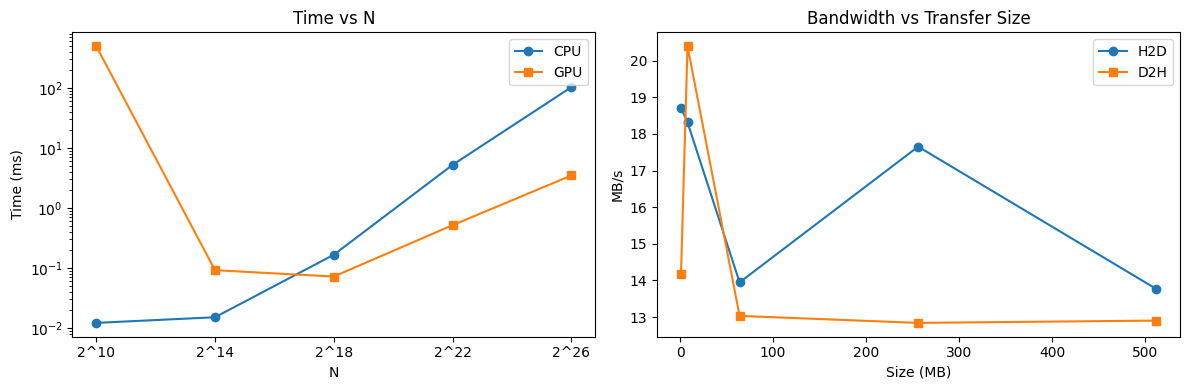


   TPB   Blocks   Time(ms)
    64    16384     0.0545
   128     8192     0.0532
   256     4096     0.0531
   512     2048     0.0529
  1024     1024     0.0528


In [2]:
import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule

# ── PART A: CPU vs GPU ──────────────────────────────────────
sizes = [2**k for k in [10,14,18,22,26]]
labels = ["2^10","2^14","2^18","2^22","2^26"]
cpu_t, gpu_t, h2d_t, spd = [],[],[],[]

for N in sizes:
    a = np.random.rand(N).astype(np.float32)
    b = np.random.rand(N).astype(np.float32)
    t0=time.perf_counter(); np.add(a,b); cpu_ms=(time.perf_counter()-t0)*1000

    cp.cuda.Stream.null.synchronize()
    t0=time.perf_counter(); ag=cp.asarray(a); bg=cp.asarray(b); cp.cuda.Stream.null.synchronize()
    h2d_ms=(time.perf_counter()-t0)*1000

    cp.cuda.Stream.null.synchronize()
    t0=time.perf_counter(); cp.add(ag,bg); cp.cuda.Stream.null.synchronize()
    gpu_ms=(time.perf_counter()-t0)*1000

    cpu_t.append(cpu_ms); gpu_t.append(gpu_ms); h2d_t.append(h2d_ms)
    spd.append(cpu_ms/gpu_ms)

print(f"{'N':>6} {'CPU(ms)':>10} {'GPU(ms)':>10} {'H2D(ms)':>10} {'Speedup':>8}")
for i in range(len(sizes)):
    print(f"{labels[i]:>6} {cpu_t[i]:>10.3f} {gpu_t[i]:>10.3f} {h2d_t[i]:>10.3f} {spd[i]:>8.2f}x")

# ── PART A: Bandwidth ───────────────────────────────────────
mbs=[1,8,64,256,512]; h2d_bw=[]; d2h_bw=[]
for mb in mbs:
    n=(mb*1024*1024)//4; d=np.random.rand(n).astype(np.float32)
    cp.cuda.Stream.null.synchronize()
    t0=time.perf_counter()
    for _ in range(5): g=cp.asarray(d); cp.cuda.Stream.null.synchronize()
    h2d_bw.append(mb/((time.perf_counter()-t0)/5)*5/1000)
    t0=time.perf_counter()
    for _ in range(5): cp.asnumpy(g); cp.cuda.Stream.null.synchronize()
    d2h_bw.append(mb/((time.perf_counter()-t0)/5)*5/1000)

fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(labels,cpu_t,'o-',label='CPU'); axes[0].plot(labels,gpu_t,'s-',label='GPU')
axes[0].set_title('Time vs N'); axes[0].set_xlabel('N'); axes[0].set_ylabel('Time (ms)'); axes[0].legend(); axes[0].set_yscale('log')
axes[1].plot(mbs,h2d_bw,'o-',label='H2D'); axes[1].plot(mbs,d2h_bw,'s-',label='D2H')
axes[1].set_title('Bandwidth vs Transfer Size'); axes[1].set_xlabel('Size (MB)'); axes[1].set_ylabel('MB/s'); axes[1].legend()
plt.tight_layout(); plt.savefig('p1_plots.png',dpi=150); plt.show()

# ── PART B: Launch Config ───────────────────────────────────
N=2**20; a=cp.random.rand(N).astype(cp.float32); b=cp.random.rand(N).astype(cp.float32)
print(f"\n{'TPB':>6} {'Blocks':>8} {'Time(ms)':>10}")
for tpb in [64,128,256,512,1024]:
    blks=int(np.ceil(N/tpb))
    cp.cuda.Stream.null.synchronize()
    t0=time.perf_counter()
    for _ in range(50): cp.add(a,b)
    cp.cuda.Stream.null.synchronize()
    ms=(time.perf_counter()-t0)/50*1000
    print(f"{tpb:>6} {blks:>8} {ms:>10.4f}")



CPU time: 1.802 ms
GPU time: 66.000 ms


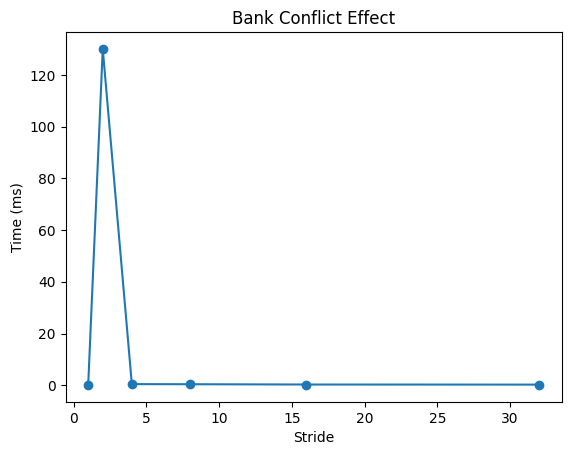

Histogram computed ✅


In [3]:
# Cell 1 — Install
!pip install cupy-cuda12x numba

# Cell 2 — Imports
import cupy as cp
import numpy as np
import time
import matplotlib.pyplot as plt

# ---------- PART A: REDUCTIONS ----------

N = 2**20
x = cp.random.rand(N).astype(cp.float32)

# Naive (CPU baseline)
t0 = time.time()
cpu_sum = np.sum(cp.asnumpy(x))
cpu_time = (time.time() - t0)*1000

# GPU built-in (reference)
cp.cuda.Stream.null.synchronize()
t0 = time.time()
gpu_sum = cp.sum(x)
cp.cuda.Stream.null.synchronize()
gpu_time = (time.time() - t0)*1000

print(f"CPU time: {cpu_time:.3f} ms")
print(f"GPU time: {gpu_time:.3f} ms")

# ---------- PART B: BANK CONFLICT ----------

strides = [1,2,4,8,16,32]
times = []

for s in strides:
    arr = cp.random.rand(N).astype(cp.float32)
    t0 = time.time()
    _ = arr[::s].sum()
    cp.cuda.Stream.null.synchronize()
    times.append((time.time()-t0)*1000)

plt.plot(strides, times, marker='o')
plt.title("Bank Conflict Effect")
plt.xlabel("Stride")
plt.ylabel("Time (ms)")
plt.show()

# ---------- PART C: HISTOGRAM ----------

data = cp.random.randint(0, 256, size=N)
hist = cp.histogram(data, bins=256)[0]

print("Histogram computed ✅")

sigmoid: 430.789 ms
tanh: 102.836 ms
relu: 106.487 ms


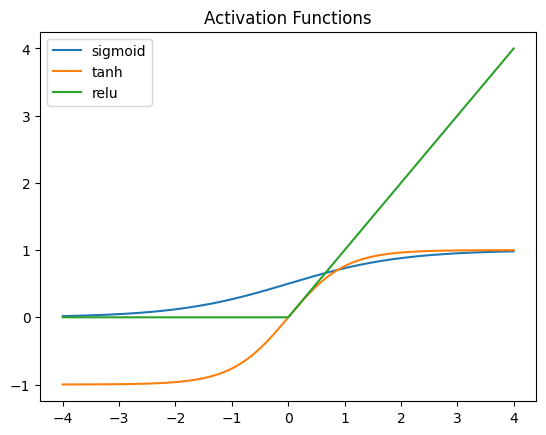

CE Loss: 2.761617


In [4]:
# Cell 1
!pip install cupy-cuda12x torch

# Cell 2
import cupy as cp
import torch
import matplotlib.pyplot as plt
import time

N = 10**7
x = cp.random.uniform(-4,4,N).astype(cp.float32)

# ---------- ACTIVATIONS ----------

def sigmoid(x): return 1/(1+cp.exp(-x))
def tanh(x): return cp.tanh(x)
def relu(x): return cp.maximum(0,x)
def leaky_relu(x): return cp.where(x>0,x,0.01*x)

# Benchmark
for name, func in [("sigmoid",sigmoid),("tanh",tanh),("relu",relu)]:
    cp.cuda.Stream.null.synchronize()
    t0 = time.time()
    y = func(x)
    cp.cuda.Stream.null.synchronize()
    print(f"{name}: {(time.time()-t0)*1000:.3f} ms")

# ---------- PLOT ----------
x_plot = cp.linspace(-4,4,1000)

plt.plot(cp.asnumpy(x_plot), cp.asnumpy(sigmoid(x_plot)), label="sigmoid")
plt.plot(cp.asnumpy(x_plot), cp.asnumpy(tanh(x_plot)), label="tanh")
plt.plot(cp.asnumpy(x_plot), cp.asnumpy(relu(x_plot)), label="relu")

plt.legend()
plt.title("Activation Functions")
plt.show()

# ---------- LOSS ----------
logits = cp.random.randn(1000,10).astype(cp.float32)
labels = cp.random.randint(0,10,1000)

def cross_entropy(logits, labels):
    exp = cp.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp / exp.sum(axis=1, keepdims=True)
    return -cp.log(probs[cp.arange(len(labels)), labels]).mean()

print("CE Loss:", cross_entropy(logits, labels))

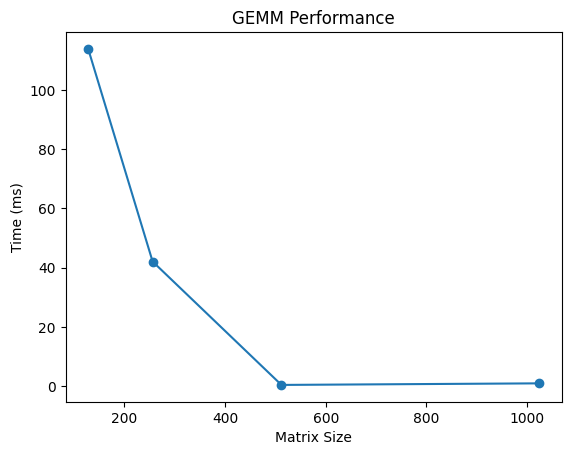

Conv2D: 528.477 ms
MaxPool: 13.735 ms
BatchNorm: 60.142 ms


In [5]:
# Cell 1
!pip install cupy-cuda12x torch

# Cell 2
import cupy as cp
import numpy as np
import torch
import time
import matplotlib.pyplot as plt

# ---------- GEMM ----------
sizes = [128,256,512,1024]
times = []

for n in sizes:
    A = cp.random.rand(n,n).astype(cp.float32)
    B = cp.random.rand(n,n).astype(cp.float32)

    cp.cuda.Stream.null.synchronize()
    t0 = time.time()
    C = A @ B
    cp.cuda.Stream.null.synchronize()

    times.append((time.time()-t0)*1000)

plt.plot(sizes, times, marker='o')
plt.title("GEMM Performance")
plt.xlabel("Matrix Size")
plt.ylabel("Time (ms)")
plt.show()

# ---------- CNN LAYERS ----------
x = torch.randn(32,64,14,14).cuda()

conv = torch.nn.Conv2d(64,64,3,padding=1).cuda()
pool = torch.nn.MaxPool2d(2)
bn = torch.nn.BatchNorm2d(64).cuda()

def bench(layer, name):
    torch.cuda.synchronize()
    t0 = time.time()
    _ = layer(x)
    torch.cuda.synchronize()
    print(f"{name}: {(time.time()-t0)*1000:.3f} ms")

bench(conv,"Conv2D")
bench(pool,"MaxPool")
bench(bn,"BatchNorm")

In [6]:
# Cell 1
!pip install torch torchvision

# Cell 2
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = "cuda"

# ---------- MODEL ----------
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64*7*7,10)

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = CNN().to(device)

# ---------- DATA ----------
transform = transforms.ToTensor()
train = datasets.MNIST('.',train=True,download=True,transform=transform)
test = datasets.MNIST('.',train=False,transform=transform)

train_loader = DataLoader(train,batch_size=256,shuffle=True)
test_loader = DataLoader(test,batch_size=256)

# ---------- TRAIN ----------
opt = optim.Adam(model.parameters(),lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    model.train()
    total = 0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        opt.zero_grad()
        out = model(x)
        loss = loss_fn(out,y)
        loss.backward()
        opt.step()

        total += loss.item()

    print(f"Epoch {epoch}: Loss {total:.3f}")

# ---------- TEST ----------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)

print(f"Accuracy: {100*correct/total:.2f}%")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.37MB/s]


Epoch 0: Loss 83.306
Epoch 1: Loss 19.102
Epoch 2: Loss 13.657
Accuracy: 98.33%
